<a href="https://colab.research.google.com/github/markajbell/BH/blob/main/ShortestPath1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Imports

In [1]:
import pandas as pd
import json
import os
import glob

Set the Path to the Data location (imported form SharpHound)

# Set the Path
to the Data location (imported from SharpHound) and Read json files in folder and create a dictionary with the entire data.





In [2]:
!wget https://raw.githubusercontent.com/markajbell/BH/refs/heads/main/adsync/secure.json
#!wget https://raw.githubusercontent.com/markajbell/BH/refs/heads/main/adsync/secure10k.json

!mkdir = "/content/adsync"
!mv secure.json /content/adsync
#!mv secure10k.json /content/adsync

path = "/content/adsync"
data = {}
json_files = glob.glob(os.path.join(path, "*.json"))
for file in json_files:
    filename = os.path.basename(file).replace(".json", "")
    suf = filename.split("_")[-1]

    with open(file, 'r', encoding='utf-8') as f:
        content = json.load(f)

    if "data" in content:
        if suf in data:
            data[f"{suf}"].extend(content["data"])
            #print(f" The key 'data' was found in {f}.")
        else:
            data[f"{suf}"] = content["data"]
            #print(f" The key 'data' was found in {f}.")
    else:
        print(f"Warning: The key 'data' was not found in {f}.")

--2025-07-21 08:54:57--  https://raw.githubusercontent.com/markajbell/BH/refs/heads/main/adsync/secure.json
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1314149 (1.3M) [text/plain]
Saving to: ‘secure.json’

secure.json         100%[===================>]   1.25M  --.-KB/s    in 0.01s   

2025-07-21 08:54:57 (109 MB/s) - ‘secure.json’ saved [1314149/1314149]



Show the "content"

In [3]:
#content


In [4]:
# prompt: if the type column = "node" save that record into a pandas dataframe called nodes, if the type = "relationship' then save to a pandas dataframe called edges

import pandas as pd
df = pd.DataFrame(data[suf])
nodes = df[df['type'] == 'node'].copy()
edges = df[df['type'] == 'relationship'].copy()
nodes['id'] = nodes['id'].astype(int)

In [5]:
# prompt: show all rows


pd.set_option('display.max_rows', None)



In [6]:
# prompt: for every record in "nodes" create a l1, l2 and l3 column for the values in "nodes.labels" eg. for record 1 l1=Base, l2=OU and l3 would be null

import pandas as pd
def extract_labels(labels):
    # Ensure labels is a list
    if not isinstance(labels, list):
        return [None, None, None]

    l1 = labels[0] if len(labels) > 0 else None
    l2 = labels[1] if len(labels) > 1 else None
    l3 = labels[2] if len(labels) > 2 else None
    return [l1, l2, l3]

# Apply the function to create the new columns
nodes[['l1', 'l2', 'l3']] = nodes['labels'].apply(lambda x: pd.Series(extract_labels(x)))


In [7]:
# prompt: remove the following columns from nodes:
# start, end, label

nodes = nodes.drop(columns=['start', 'end', 'label', 'labels'])


In [8]:

edges = edges.drop(columns=['labels'])


Expand "Properties" column in new columns.

Convert to Dict

In [9]:
pd.set_option("display.max_rows", None, "display.max_columns", None)

#nodes

In [10]:
#edges = edges.drop(columns=['id'])
import numpy as np
edges['id'] = np.arange(len(edges)).astype('int64')


In [11]:
# prompt: save the df_compuers as json to content

# import json

# # Assuming df_computers is already defined as in your provided code.

# # Convert the DataFrame to a JSON string.
# nodes_json = nodes.to_json(orient='records')

# # Save the JSON string to a file named 'content.json'.
# with open('nodes.json', 'w') as f:
#   f.write(nodes_json)


In [12]:
# prompt: save the df_compuers as json to content

# import json

# # Assuming df_computers is already defined as in your provided code.

# # Convert the DataFrame to a JSON string.
# edges_json = edges.to_json(orient='records')

# # Save the JSON string to a file named 'content.json'.
# with open('edges.json', 'w') as f:
#   f.write(edges_json)

In [13]:
# prompt: create a new column in nodes called weight

nodes['weight'] = 1

In [56]:
pd.set_option("display.max_rows", None, "display.max_columns", None)
pd.set_option('display.max_colwidth', None)

nodes.tail()

,id,properties,type,l1,l2,l3,weight
1292,1292,"{'domain': 'MARK.LOCAL', 'name': 'T2_HR_Folder45_Full@MARK.LOCAL', 'objectid': 'S-1-5-21-883232822-274137685-4173207997-2009', 'distinguishedname': 'CN=T2_HR_FOLDER45_FULL,OU=T2 Security HR,OU=T2 Security Groups,OU=T2 Groups,OU=Tier 2,DC=MARK,DC=LOCAL', 'description': 'This is a security group', 'highvalue': False, 'admincount': False, 'owned': False}",node,Base,Group,None,5
1293,1293,"{'domain': 'MARK.LOCAL', 'name': 'T2_HR_Folder46_Full@MARK.LOCAL', 'objectid': 'S-1-5-21-883232822-274137685-4173207997-2010', 'distinguishedname': 'CN=T2_HR_FOLDER46_FULL,OU=T2 Security HR,OU=T2 Security Groups,OU=T2 Groups,OU=Tier 2,DC=MARK,DC=LOCAL', 'description': 'This is a security group', 'highvalue': False, 'admincount': False, 'owned': False}",node,Base,Group,None,5
1294,1294,"{'domain': 'MARK.LOCAL', 'name': 'T2_HR_Folder47_Full@MARK.LOCAL', 'objectid': 'S-1-5-21-883232822-274137685-4173207997-2011', 'distinguishedname': 'CN=T2_HR_FOLDER47_FULL,OU=T2 Security HR,OU=T2 Security Groups,OU=T2 Groups,OU=Tier 2,DC=MARK,DC=LOCAL', 'description': 'This is a security group', 'highvalue': False, 'admincount': False, 'owned': False}",node,Base,Group,None,5
1295,1295,"{'domain': 'MARK.LOCAL', 'name': 'T2_HR_Folder48_Full@MARK.LOCAL', 'objectid': 'S-1-5-21-883232822-274137685-4173207997-2012', 'distinguishedname': 'CN=T2_HR_FOLDER48_FULL,OU=T2 Security HR,OU=T2 Security Groups,OU=T2 Groups,OU=Tier 2,DC=MARK,DC=LOCAL', 'description': 'This is a security group', 'highvalue': False, 'admincount': False, 'owned': False}",node,Base,Group,None,5
1296,1296,"{'domain': 'MARK.LOCAL', 'name': 'T2_HR_Folder49_Full@MARK.LOCAL', 'objectid': 'S-1-5-21-883232822-274137685-4173207997-2013', 'distinguishedname': 'CN=T2_HR_FOLDER49_FULL,OU=T2 Security HR,OU=T2 Security Groups,OU=T2 Groups,OU=Tier 2,DC=MARK,DC=LOCAL', 'description': 'This is a security group', 'highvalue': False, 'admincount': False, 'owned': False}",node,Base,Group,None,5


In [15]:
# 1/0
# tier0_node_ids = nodes[nodes['properties'].apply(lambda x: 'Tier 0' in x.get('distinguishedname', ''))]['id'].tolist()
# tier0_node_ids

tier0_node_ids = nodes[
    nodes['properties'].apply(
        lambda x: any(
            term in x.get('distinguishedname', '')
            for term in ['TIER 0', 'Tier 0', 'T0']
        )
    )
]['id'].tolist()


tier1_node_ids = nodes[
    nodes['properties'].apply(
        lambda x: any(
            term in x.get('distinguishedname', '')
            for term in ['TIER 1', 'Tier 1', 'T1']
        )
    )
]['id'].tolist()

tier2_node_ids = nodes[
    nodes['properties'].apply(
        lambda x: any(
            term in x.get('distinguishedname', '')
            for term in ['TIER 2', 'Tier 2', 'T2']
        )
    )
]['id'].tolist()

print(f"tier 0 ",len(tier0_node_ids))
# tier1_node_ids = nodes[nodes['properties'].apply(lambda x: 'Tier 1' in x.get('distinguishedname', ''))]['id'].tolist()
print(f"tier 1 ",len(tier1_node_ids))

# tier2_node_ids = nodes[nodes['properties'].apply(lambda x: 'Tier 2' in x.get('distinguishedname', ''))]['id'].tolist()
print(f"tier 2 ",len(tier2_node_ids))

tier 0  42
tier 1  58
tier 2  949


In [68]:
# prompt: show me where nodes[properties]highvalue = true, then append int(node['id']) if not already in tier0_node_ids

for index, node in nodes.iterrows():
    if 'properties' in node and 'highvalue' in node['properties'] and node['properties']['highvalue'] == True:
        node_id_int = int(node['id'])
        if node_id_int not in tier0_node_ids:
            tier0_node_ids.append(node_id_int)

In [70]:
len(tier0_node_ids)

142

In [16]:
len(nodes)

1297

In [71]:

for value in tier0_node_ids:
    nodes.loc[nodes['id'] == value, 'weight'] = 20

for value in tier1_node_ids:
    nodes.loc[nodes['id'] == value, 'weight'] = 10

for value in tier2_node_ids:
    nodes.loc[nodes['id'] == value, 'weight'] = 5

#nodes.head(50)

In [18]:
# prompt: get a unique list of label from edges and save it to list called edges_labels

edges_labels = edges['label'].unique().tolist()

In [19]:
# Apply the weights based on the 'label' column

def assign_weight(label):
    if label == "GenericAll":
        return 9
    elif label == "Owns":
        return 10
    elif label == "GenericWrite":
        return 2
    elif label == "AllExtendedRights":
        return 6
    elif label == "CanRDP":
        return 2
    elif label == "Contains":
        return 2
    elif label == "DCSync":
        return 8
    elif label == "WriteDacl":
        return 5
    elif label == "WriteOwner":
        return 7
    elif label == "AddKeyCredentialLink":
        return 6
    elif label == "AdminTo":
        return 8
    elif label == "MemberOf":
        return 1
    elif label == "CanPSRemote":
        return 2
    elif label == "ExecuteDCOM":
        return 2
    elif label == "GPLink":
        return 3
    elif label == "HasSession":
        return 9
    elif label == "ReadLAPSPassword":
        return 2
    elif label == "GetChanges":
        return 3
    elif label == "GetChangesAll":
        return 3
    elif label == "AddSelf":
        return 3
    elif label == "ForceChangePassword":
        return 3
    elif label == "AddMember":
        return 5
    elif label == "tier0":
        return 20
    else:
        return 1 # Default weight for other labels

edges['weight'] = edges['label'].apply(assign_weight)

# Display the updated edges_all DataFrame with the 'weight' column
print("\nEdges_all DataFrame with weight column:")
#edges.head(50)
#clear_output()


Edges_all DataFrame with weight column:


In [20]:
# prompt: from edges['start'] get 'id' and from edges['end] get 'id'
# replace start with edges['start'][id'] and  end with edges['end']['id']

edges['start'] = edges['start'].apply(lambda x: x.get('id') if isinstance(x, dict) else x)
edges['end'] = edges['end'].apply(lambda x: x.get('id') if isinstance(x, dict) else x)

In [21]:
len(edges)

3974

In [22]:
print("\nEdges_all DataFrame with weight column:")
edges.tail(50)


Edges_all DataFrame with weight column:


,id,properties,type,start,end,label,weight
5221,3924,"{'isacl': True, 'isInherited': True, 'inheritanceType': 'All'}",relationship,36,11,WriteOwner,7
5222,3925,"{'isacl': True, 'isInherited': True, 'inheritanceType': 'All'}",relationship,36,15,WriteOwner,7
5223,3926,"{'isacl': True, 'isInherited': True, 'inheritanceType': 'All'}",relationship,36,14,WriteOwner,7
5224,3927,"{'isacl': True, 'isInherited': True, 'inheritanceType': 'All'}",relationship,36,18,WriteOwner,7
5225,3928,"{'isacl': True, 'isInherited': True, 'inheritanceType': 'All'}",relationship,36,24,WriteOwner,7
5226,3929,"{'isacl': True, 'isInherited': False, 'inheritanceType': 'All'}",relationship,66,98,WriteOwner,7
5227,3930,"{'isacl': True, 'isInherited': False, 'inheritanceType': 'All'}",relationship,65,98,WriteOwner,7
5228,3931,"{'isacl': True, 'isInherited': False, 'inheritanceType': 'All'}",relationship,60,8,GenericAll,9
5229,3932,"{'isacl': True, 'isInherited': False, 'inheritanceType': 'All'}",relationship,60,12,GenericAll,9
5230,3933,"{'isacl': True, 'isInherited': False, 'inheritanceType': 'All'}",relationship,60,16,GenericAll,9


In [23]:

edges = edges.drop(columns=['properties', 'id'])

In [24]:
# prompt: create a unique id for each row, make sure it is of type int64
#edges = edges.drop(columns=['id'])
import numpy as np
edges['id'] = np.arange(len(edges)).astype('int64')
edges.head()
edges['id'].dtype

dtype('int64')

In [25]:
# prompt: create a unique id for each row, make sure it is of type int64

import numpy as np
edges['id'] = np.arange(len(edges)).astype('int64')

In [26]:

edges.keys()

Index(['type', 'start', 'end', 'label', 'weight', 'id'], dtype='object')

In [27]:
edges.head()

,type,start,end,label,weight,id
1297,relationship,0,1,Contains,2,0
1298,relationship,0,2,Contains,2,1
1299,relationship,0,3,Contains,2,2
1300,relationship,1,4,Contains,2,3
1301,relationship,1,5,Contains,2,4


In [72]:
# prompt: filter where edges['id'] = tier2_node_ids and call the dataframe selected_ddges

selected_edges = edges[edges['end'].isin(tier0_node_ids)]
selected_edges

,type,start,end,label,weight,id
1300,relationship,1,4,Contains,2,3
1303,relationship,4,7,Contains,2,6
1304,relationship,4,8,Contains,2,7
1305,relationship,4,9,Contains,2,8
1306,relationship,4,10,Contains,2,9
1332,relationship,9,65,Contains,2,35
1333,relationship,9,66,Contains,2,36
1334,relationship,9,36,Contains,2,37
1336,relationship,9,60,Contains,2,39
1337,relationship,9,40,Contains,2,40


In [29]:
# prompt: make edges['start'] and edges['end'] int64

edges['start'] = edges['start'].astype('int64')
edges['end'] = edges['end'].astype('int64')

In [30]:
edges.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3974 entries, 1297 to 5270
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   type    3974 non-null   object
 1   start   3974 non-null   int64 
 2   end     3974 non-null   int64 
 3   label   3974 non-null   object
 4   weight  3974 non-null   int64 
 5   id      3974 non-null   int64 
dtypes: int64(4), object(2)
memory usage: 217.3+ KB


In [31]:
# prompt: selected_edges_t0 = edges[edges['end'].isin(tier0_node_ids)] and selected_edges_t0=edges[edges'start'] is not in tier0_node_ids

selected_edges_t0 = edges[
    (edges['end'].isin(tier0_node_ids))
#    & (~edges['start'].isin(tier0_node_ids))
]
len(selected_edges_t0)

136

In [32]:
selected_edges_t1 = edges[edges['start'].isin(tier1_node_ids)]
#selected_edges_t1
selected_edges_t2 = edges[edges['start'].isin(tier2_node_ids)]
#selected_edges_t2

In [33]:
selected_nodes = nodes[nodes['id'].isin(tier2_node_ids)]

In [73]:
len(selected_edges_t0)

136

In [74]:
import networkx as nx

# Create a directed graph
G = nx.DiGraph()

# Add nodes with their weights
for index, row in selected_nodes.iterrows():
    # Ensure node IDs are integers when adding to the graph
    G.add_node(int(row['id']), weight=row['weight'])

# Add edges with their weights
for index, row in selected_edges_t0.iterrows():
    # Ensure edge endpoints are integers when adding to the graph
    G.add_edge(row['start'], row['end'], weight=row['weight'])

# Compute shortest paths from each source node to all reachable nodes
shortest_paths = {}
for source in G.nodes():
    # Use single_source_dijkstra_path to find paths from one source to all others
    shortest_paths[source] = nx.single_source_dijkstra_path(G, source)

# Filter out paths from a node to itself and store in a new dictionary
shortest_paths_filtered = {
    source: {
        target: path
        for target, path in paths.items()
        if source != target
        #if target in tier0_node_ids
        #if source in tier0_node_ids
    }
    for source, paths in shortest_paths.items()
}

# Print the shortest paths (optional)
for source, paths in shortest_paths_filtered.items():
  if paths:
    #print(f"Shortest paths from node {source}:")
    for target, path in paths.items():
        #print(f"  To node {target}: {path}")
        ShortestPath = source, target, path
       # print(ShortestPath)

In [75]:
# prompt: show only records where shortest_paths_filtered is not empty. Sort by source

import pandas as pd
# Convert the dictionary to a list of dictionaries
data_list = []
for source, paths in shortest_paths_filtered.items():
    for target, path in paths.items():
        data_list.append({'source': source, 'target': target, 'path': path})

# Create a DataFrame from the list of dictionaries
shortest_paths_df = pd.DataFrame(data_list)

# Filter out records where the 'path' is empty (which implies shortest_paths_filtered is not empty for that source-target pair)
# Since we constructed the DataFrame only from non-empty paths, this step is redundant based on the previous loop,
# but it's good practice if the filtering logic changed.
# A more direct way to check for non-empty paths after DataFrame creation would involve examining the 'path' column length.
# However, the current structure of `data_list` creation ensures that only non-empty paths are included.

# Sort by 'source'
shortest_paths_df_sorted = shortest_paths_df.sort_values(by='source')

# Print the resulting DataFrame
#shortest_paths_df_sorted

In [37]:
#shortest_paths_filtered

In [76]:
# prompt: using the above code, save all ShortestPath to a json file

shortest_paths_list = []
for source, paths in shortest_paths_filtered.items():
    if paths:
        for target, path in paths.items():
            shortest_paths_list.append({
                'source': source,
                'target': target,
                'path': path,
            })

with open('shortest_paths.json', 'w') as f:
    json.dump(shortest_paths_list, f, indent=4)

print("Shortest paths saved to shortest_paths.json")


Shortest paths saved to shortest_paths.json


In [77]:
# prompt: save the df_compuers as json to content

import json

# Assuming df_computers is already defined as in your provided code.

# Convert the DataFrame to a JSON string.
selected_edges_json = selected_edges_t2.to_json(orient='records')

# Save the JSON string to a file named 'content.json'.
with open('selected_edges_t2.json', 'w') as f:
  f.write(selected_edges_json)

In [78]:
# prompt: save the df_compuers as json to content

import json

# Assuming df_computers is already defined as in your provided code.

# Convert the DataFrame to a JSON string.
selected_nodes_json = selected_nodes.to_json(orient='records')

# Save the JSON string to a file named 'content.json'.
with open('selected_nodes.json', 'w') as f:
  f.write(selected_nodes_json)

In [79]:
# prompt: export shortest_paths_filtered to json and save as shortest_paths_filtered_json

shortest_paths_filtered_json = json.dumps(ShortestPath, indent=2)

# Optionally, save the JSON string to a file
with open('ShortestPath.json', 'w') as f:
  f.write(shortest_paths_filtered_json)

In [80]:
# prompt: find the corresponding record in edges where (edges['start']=shortest_paths_list['source']) and (edges['end']=shortest_paths_list['target'] and then add up the weight

# Calculate the total weight for each shortest path
shortest_paths_with_weight = []
for path_info in shortest_paths_list:
    total_weight = 0
    # The path is a list of node IDs
    path = path_info['path']
    # Iterate through the path to get the edges
    for i in range(len(path) - 1):
        start_node = path[i]
        end_node = path[i+1]
        # Find the corresponding edge in the 'edges' DataFrame
        # There might be multiple edges between two nodes, so we sum up weights if needed
        # For shortest path, we typically consider the direct edge weight
        edge = edges[(edges['start'] == start_node) & (edges['end'] == end_node)]
        if not edge.empty:
            # Assuming there is only one edge with this start and end for simplicity in path finding
            # If multiple edges exist, you might need to adjust based on which edge is part of the shortest path calculation
            total_weight += edge.iloc[0]['weight']
    path_info['total_weight'] = total_weight
    shortest_paths_with_weight.append(path_info)

# Print or use the shortest_paths_with_weight list
#for path_info in shortest_paths_with_weight:
 #   print(f"Path from {path_info['source']} to {path_info['target']}: {path_info['path']} - Total Weight: {path_info['total_weight']}")


In [81]:
# prompt: convert shortest_paths_with_weight to dataframe called df_shortest_paths_with_weight

import pandas as pd
df_shortest_paths_with_weight = pd.DataFrame(shortest_paths_with_weight)

In [83]:
# prompt: from df_shortest_paths_with_weight find the min and max weight, source target and path. only include paths where the source is not in tier0_node_ids and target is in tier0_node_ids

df_filtered_paths = df_shortest_paths_with_weight[
    (~df_shortest_paths_with_weight['source'].isin(tier0_node_ids)) &
    (df_shortest_paths_with_weight['target'].isin(tier0_node_ids))
].copy()

if not df_filtered_paths.empty:
    min_weight_row = df_filtered_paths.loc[df_filtered_paths['total_weight'].idxmin()]
    max_weight_row = df_filtered_paths.loc[df_filtered_paths['total_weight'].idxmax()]

    print("Min Weight Path:")
    print(f"  Source: {min_weight_row['source']}")
    print(f"  Target: {min_weight_row['target']}")
    print(f"  Path: {min_weight_row['path']}")
    print(f"  Weight: {min_weight_row['total_weight']}")

    print("\nMax Weight Path:")
    print(f"  Source: {max_weight_row['source']}")
    print(f"  Target: {max_weight_row['target']}")
    print(f"  Path: {max_weight_row['path']}")
    print(f"  Weight: {max_weight_row['total_weight']}")
else:
    print("No paths found that start outside Tier 0 and end in Tier 0.")

Min Weight Path:
  Source: 110
  Target: 8
  Path: [110, 8]
  Weight: 1

Max Weight Path:
  Source: 869
  Target: 303
  Path: [869, 8, 686, 303]
  Weight: 13


In [97]:
min_weight_row

,196
source,110
target,8
path,"[110, 8]"
total_weight,1


In [93]:
# prompt: for value pairs max_weight_row['path'] show weights in edges

if not df_filtered_paths.empty:
    max_weight_row = df_filtered_paths.loc[df_filtered_paths['total_weight'].idxmax()]
    print("\nMax Weight Path (with edge weights):")
    print(f"  Source: {max_weight_row['source']}")
    print(f"  Target: {max_weight_row['target']}")
    print(f"  Path: {max_weight_row['path']}")
    print(f"  Weight: {max_weight_row['total_weight']}")

    # Iterate through the path to show edge weights
    path = max_weight_row['path']
    for i in range(len(path) - 1):
        start_node = path[i]
        end_node = path[i+1]
        edge = edges[(edges['start'] == start_node) & (edges['end'] == end_node)]
        if not edge.empty:
            print(f"    Edge from {start_node} to {end_node} (Label: {edge.iloc[0]['label']}): Weight = {edge.iloc[0]['weight']}")
else:
    print("No paths found that start outside Tier 0 and end in Tier 0.")


Max Weight Path (with edge weights):
  Source: 869
  Target: 303
  Path: [869, 8, 686, 303]
  Weight: 13
    Edge from 869 to 8 (Label: CanRDP): Weight = 2
    Edge from 8 to 686 (Label: Contains): Weight = 2
    Edge from 686 to 303 (Label: HasSession): Weight = 9


In [98]:
 #prompt: for value pairs max_weight_row['path'] show weights in edges

if not df_filtered_paths.empty:
    min_weight_row = df_filtered_paths.loc[df_filtered_paths['total_weight'].idxmin()]
    #min_weight_row = df_filtered_paths.loc[df_filtered_paths['total_weight'].idxmin()]
    print("\nMin Weight Path (with edge weights):")
    print(f"  Source: {min_weight_row['source']}")
    print(f"  Target: {min_weight_row['target']}")
    print(f"  Path: {min_weight_row['path']}")
    print(f"  Weight: {min_weight_row['total_weight']}")

    # Iterate through the path to show edge weights
    path = min_weight_row['path']
    for i in range(len(path) - 1):
        start_node = path[i]
        end_node = path[i+1]
        edge = edges[(edges['start'] == start_node) & (edges['end'] == end_node)]
        if not edge.empty:
            print(f"    Edge from {start_node} to {end_node} (Label: {edge.iloc[0]['label']}): Weight = {edge.iloc[0]['weight']}")
else:
    print("No paths found that start outside Tier 0 and end in Tier 0.")


Min Weight Path (with edge weights):
  Source: 110
  Target: 8
  Path: [110, 8]
  Weight: 1
    Edge from 110 to 8 (Label: GpLink): Weight = 1


In [106]:
print(nodes[nodes['id'] == 110])
print(nodes[nodes['id'] == 36])
print(nodes[nodes['id'] == 869])
print(nodes[nodes['id'] == 8])
print(nodes[nodes['id'] == 686])
print(nodes[nodes['id'] == 303])

      id  \
110  110   

                                                                                                                                                                       properties  \
110  {'domain': 'MARK.LOCAL', 'name': 'PAW Configuration@MARK.LOCAL', 'objectid': 'S-1-5-21-883232822-274137685-4173207997-d37c9c32-7ad3-4495-862c-b8c9734a1860', 'owned': False}   

     type    l1   l2    l3  weight  
110  node  Base  GPO  None       1  
    id  \
36  36   

                                                                                                                                                                                                                                                                                                                         properties  \
36  {'domain': 'MARK.LOCAL', 'name': 'ADMINISTRATORS@MARK.LOCAL', 'objectid': 'MARK.LOCAL-S-1-5-32-544', 'highvalue': True, 'distinguishedname': 'CN=Administrators,CN=Builtin,DC=MARK,DC=LOCA

In [87]:
# prompt: filter all weights from df_shortest_paths_with_weight with the minimum total weight

# Find the minimum total weight
min_total_weight = df_shortest_paths_with_weight['total_weight'].min()
# Filter the DataFrame to get rows with the minimum total weight
df_min_weight_paths = df_shortest_paths_with_weight[df_shortest_paths_with_weight['total_weight'] == min_total_weight]
# Print the DataFrame with minimum total weight
print("\nPaths with the Minimum Total Weight:")
df_min_weight_paths


Paths with the Minimum Total Weight:


,source,target,path,total_weight
196,110,8,"[110, 8]",1
220,111,8,"[111, 8]",1
244,135,9,"[135, 9]",1
245,137,4,"[137, 4]",1
276,139,9,"[139, 9]",1
277,141,10,"[141, 10]",1
280,147,4,"[147, 4]",1
311,160,9,"[160, 9]",1
312,172,4,"[172, 4]",1
343,179,10,"[179, 10]",1


In [108]:
# prompt: filter df_shortest_paths_with_weight where start is not in tier0_node_ids

df_filtered = df_shortest_paths_with_weight[~df_shortest_paths_with_weight['source'].isin(tier0_node_ids)]
df_filtered

,source,target,path,total_weight
0,15,301,"[15, 301]",2
1,15,318,"[15, 318]",2
2,26,331,"[26, 331]",2
3,26,341,"[26, 341]",2
4,26,357,"[26, 357]",2
5,26,405,"[26, 405]",2
6,26,444,"[26, 444]",2
7,26,448,"[26, 448]",2
8,27,392,"[27, 392]",2
9,29,481,"[29, 481]",2


In [128]:
# prompt: filter all weights from df_shortest_paths_with_weight with the minimum total weight

# Find the minimum total weight

min_total_weight = df_filtered['total_weight'].min()
# Filter the DataFrame to get rows with the minimum total weight
df_min_weight_paths = df_shortest_paths_with_weight[df_shortest_paths_with_weight['total_weight'] == min_total_weight]
# Print the DataFrame with minimum total weight
print("\nPaths with the Minimum Total Weight:")
df_min_weight_paths


Paths with the Minimum Total Weight:


,source,target,path,total_weight
196,110,8,"[110, 8]",1
220,111,8,"[111, 8]",1
244,135,9,"[135, 9]",1
245,137,4,"[137, 4]",1
276,139,9,"[139, 9]",1
277,141,10,"[141, 10]",1
280,147,4,"[147, 4]",1
311,160,9,"[160, 9]",1
312,172,4,"[172, 4]",1
343,179,10,"[179, 10]",1


In [129]:
# prompt: filter all weights from df_shortest_paths_with_weight with the minimum total weight

# Find the minimum total weight

max_total_weight = df_filtered['total_weight'].max()
# Filter the DataFrame to get rows with the minimum total weight
df_max_weight_paths = df_shortest_paths_with_weight[df_shortest_paths_with_weight['total_weight'] == max_total_weight]
# Print the DataFrame with minimum total weight
print("\nPaths with the Maximum Total Weight:")
df_max_weight_paths


Paths with the Maximum Total Weight:


,source,target,path,total_weight
69,869,303,"[869, 8, 686, 303]",13
70,869,296,"[869, 8, 527, 296]",13
71,869,305,"[869, 8, 607, 305]",13
72,869,457,"[869, 8, 610, 457]",13
73,869,324,"[869, 8, 625, 324]",13
74,869,307,"[869, 8, 631, 307]",13
75,869,692,"[869, 8, 653, 692]",13
76,869,458,"[869, 8, 653, 458]",13
93,871,303,"[871, 8, 686, 303]",13
94,871,296,"[871, 8, 527, 296]",13


In [119]:
# prompt: for each value in df_max_weight_paths['paths'] count the values and sort in ascending order with largest first

from collections import Counter

# Count the occurrences of each value in the 'paths' column
path_value_counts = Counter(item for sublist in df_max_weight_paths['path'] for item in sublist)

# Sort the counts in descending order (largest first)
sorted_path_value_counts = dict(sorted(path_value_counts.items(), key=lambda item: item[1], reverse=True))

print("\nCounts of values in paths (sorted in descending order):")
for value, count in sorted_path_value_counts.items():
    print(f"Value: {value}, Count: {count}")



Counts of values in paths (sorted in descending order):
Value: 8, Count: 16
Value: 869, Count: 8
Value: 871, Count: 8
Value: 653, Count: 4
Value: 686, Count: 2
Value: 303, Count: 2
Value: 527, Count: 2
Value: 296, Count: 2
Value: 607, Count: 2
Value: 305, Count: 2
Value: 610, Count: 2
Value: 457, Count: 2
Value: 625, Count: 2
Value: 324, Count: 2
Value: 631, Count: 2
Value: 307, Count: 2
Value: 692, Count: 2
Value: 458, Count: 2


In [130]:
# prompt: for each value in df_max_weight_paths['paths'] count the values and sort in ascending order with largest first

from collections import Counter

# Count the occurrences of each value in the 'paths' column
min_path_value_counts = Counter(item for sublist in df_min_weight_paths['path'] for item in sublist)

# Sort the counts in descending order (largest first)
min_sorted_path_value_counts = dict(sorted(min_path_value_counts.items(), key=lambda item: item[1], reverse=True))

print("\nCounts of values in paths (sorted in descending order):")
for value, count in min_sorted_path_value_counts.items():
    print(f"Value: {value}, Count: {count}")


Counts of values in paths (sorted in descending order):
Value: 10, Count: 9
Value: 9, Count: 4
Value: 4, Count: 4
Value: 8, Count: 2
Value: 7, Count: 2
Value: 110, Count: 1
Value: 111, Count: 1
Value: 135, Count: 1
Value: 137, Count: 1
Value: 139, Count: 1
Value: 141, Count: 1
Value: 147, Count: 1
Value: 160, Count: 1
Value: 172, Count: 1
Value: 179, Count: 1
Value: 184, Count: 1
Value: 186, Count: 1
Value: 187, Count: 1
Value: 188, Count: 1
Value: 200, Count: 1
Value: 208, Count: 1
Value: 219, Count: 1
Value: 237, Count: 1
Value: 258, Count: 1
Value: 262, Count: 1
Value: 272, Count: 1


In [121]:
# prompt: count the values from df_max_weight_paths['source']

source_counts = df_max_weight_paths['source'].value_counts()

print("\nCounts of values in df_max_weight_paths['source']:")
source_counts


Counts of values in df_max_weight_paths['source']:


,count
source,
869,8
871,8


In [131]:
# prompt: count the values from df_max_weight_paths['source']

source_counts = df_min_weight_paths['source'].value_counts()

print("\nCounts of values in df_max_weight_paths['source']:")
source_counts


Counts of values in df_max_weight_paths['source']:


,count
source,
110,1
111,1
135,1
137,1
139,1
141,1
147,1
160,1
172,1


In [132]:
# prompt: nodes['id']=869

print(nodes.loc[nodes['id'] == 111])
print(nodes.loc[nodes['id'] == 135])


      id  \
111  111   

                                                                                                                                                                               properties  \
111  {'domain': 'MARK.LOCAL', 'name': 'PAW Outbound restrictions@MARK.LOCAL', 'objectid': 'S-1-5-21-883232822-274137685-4173207997-cf2a4368-3679-4e69-aa93-21b1f7521bc6', 'owned': False}   

     type    l1   l2    l3  weight  
111  node  Base  GPO  None       1  
      id  \
135  135   

                                                                                                                                                                                                  properties  \
135  {'domain': 'MARK.LOCAL', 'name': 'Network_Restriction_21@MARK.LOCAL', 'objectid': 'S-1-5-21-883232822-274137685-4173207997-92f07622-6fbb-4bf7-821c-b8ff1dd4cb90', 'exploitable': False, 'owned': False}   

     type    l1   l2    l3  weight  
135  node  Base  GPO  None       1  


In [133]:
# prompt: df_min_weight_paths dtype

df_min_weight_paths.dtypes

#df_max_weight_paths.dtypes

,0
source,int64
target,int64
path,object
total_weight,int64


In [134]:
# prompt: Using dataframe df_min_weight_paths: filter where source is in tier2_node_ids and target is in tier0_node_ids

# Filter the dataframe based on the conditions for 'source' and 'target'
df_min_weight_paths_filtered = df_min_weight_paths[(df_min_weight_paths['source'].isin(tier2_node_ids)) ]
df_min_weight_paths_filtered

,source,target,path,total_weight


In [112]:
min_weight_row

,196
source,110
target,8
path,"[110, 8]"
total_weight,1


In [51]:
print(nodes[nodes['id'] == 60])
# print(nodes[nodes['id'] == 8])
# print(nodes[nodes['id'] == 686])
# print(nodes[nodes['id'] == 303])
#print(nodes[nodes['id'] == 331])
#print(nodes[nodes['id'] == 208])

    id  \
60  60   

                                                                                                                                                                                                                                                                                                         properties  \
60  {'domain': 'MARK.LOCAL', 'name': 'ACCOUNT OPERATORS@MARK.LOCAL', 'objectid': 'MARK.LOCAL-S-1-5-32-548', 'highvalue': True, 'distinguishedname': 'CN=Account Operators,CN=Builtin,DC=MARK,DC=LOCAL', 'description': 'Members can administer domain user and group accounts', 'admincount': True, 'owned': False}   

    type    l1     l2    l3  weight  
60  node  Base  Group  None       1  


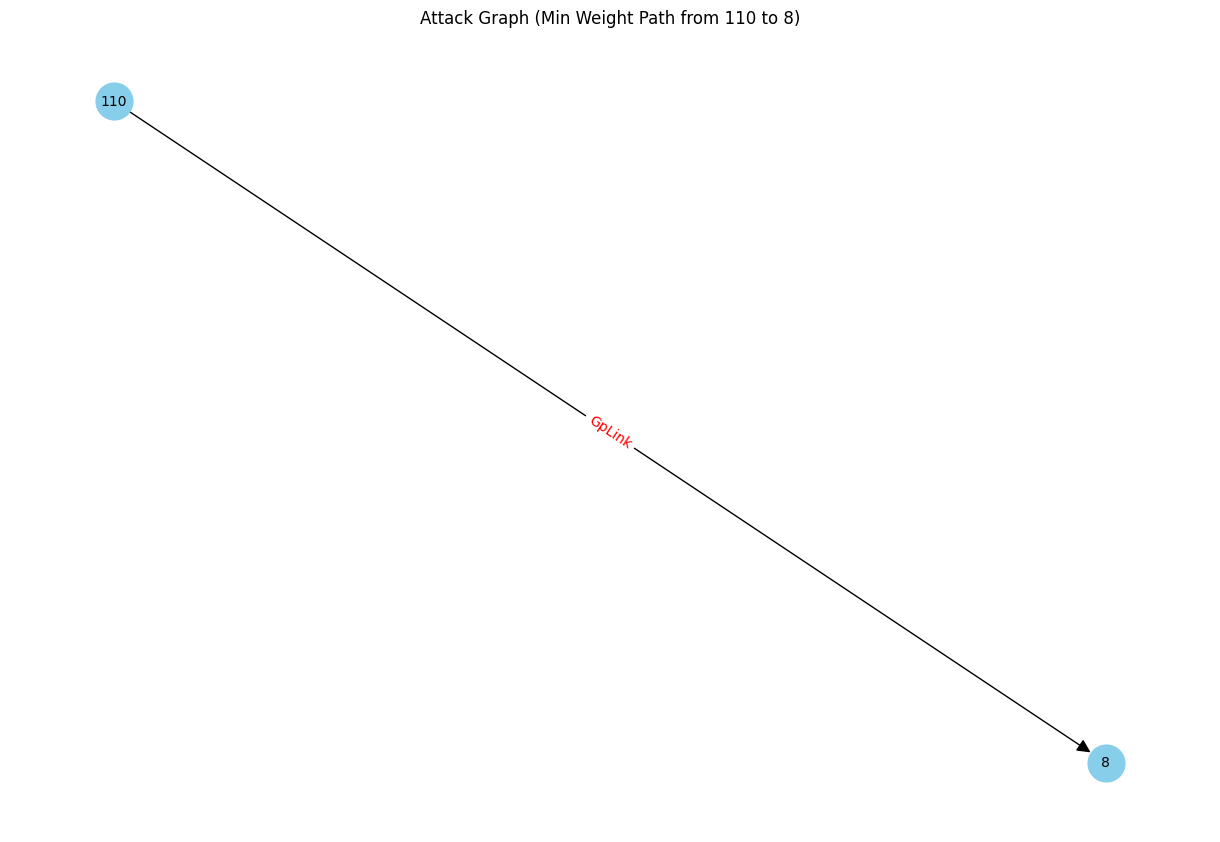

In [135]:
# prompt: using min_weight_row plot the attack graph using networkx

import matplotlib.pyplot as plt

# Create a graph for the attack path
attack_graph = nx.DiGraph()

# Add nodes from the min_weight_row path
path_nodes = min_weight_row['path']
for node_id in path_nodes:
    # Find the node properties from the original 'nodes' DataFrame
    node_info = nodes[nodes['id'] == node_id].iloc[0]
    attack_graph.add_node(node_id, label=node_info.get('name', str(node_id)), weight=node_info.get('weight', 1))

# Add edges from the min_weight_row path
for i in range(len(path_nodes) - 1):
    start_node = path_nodes[i]
    end_node = path_nodes[i+1]
    # Find the edge properties from the original 'edges' DataFrame
    edge_info = edges[(edges['start'] == start_node) & (edges['end'] == end_node)].iloc[0]
    attack_graph.add_edge(start_node, end_node, label=edge_info.get('label', 'Unknown'), weight=edge_info.get('weight', 1))

# Draw the graph
pos = nx.spring_layout(attack_graph)  # You can choose a different layout

plt.figure(figsize=(12, 8))
nx.draw(attack_graph, pos, with_labels=False, node_size=700, node_color='skyblue', font_size=10, arrowsize=20)

# Add node labels
node_labels = nx.get_node_attributes(attack_graph, 'label')
nx.draw_networkx_labels(attack_graph, pos, labels=node_labels, font_size=10)

# Add edge labels
edge_labels = nx.get_edge_attributes(attack_graph, 'label')
nx.draw_networkx_edge_labels(attack_graph, pos, edge_labels=edge_labels, font_color='red')

plt.title(f"Attack Graph (Min Weight Path from {min_weight_row['source']} to {min_weight_row['target']})")
plt.show()

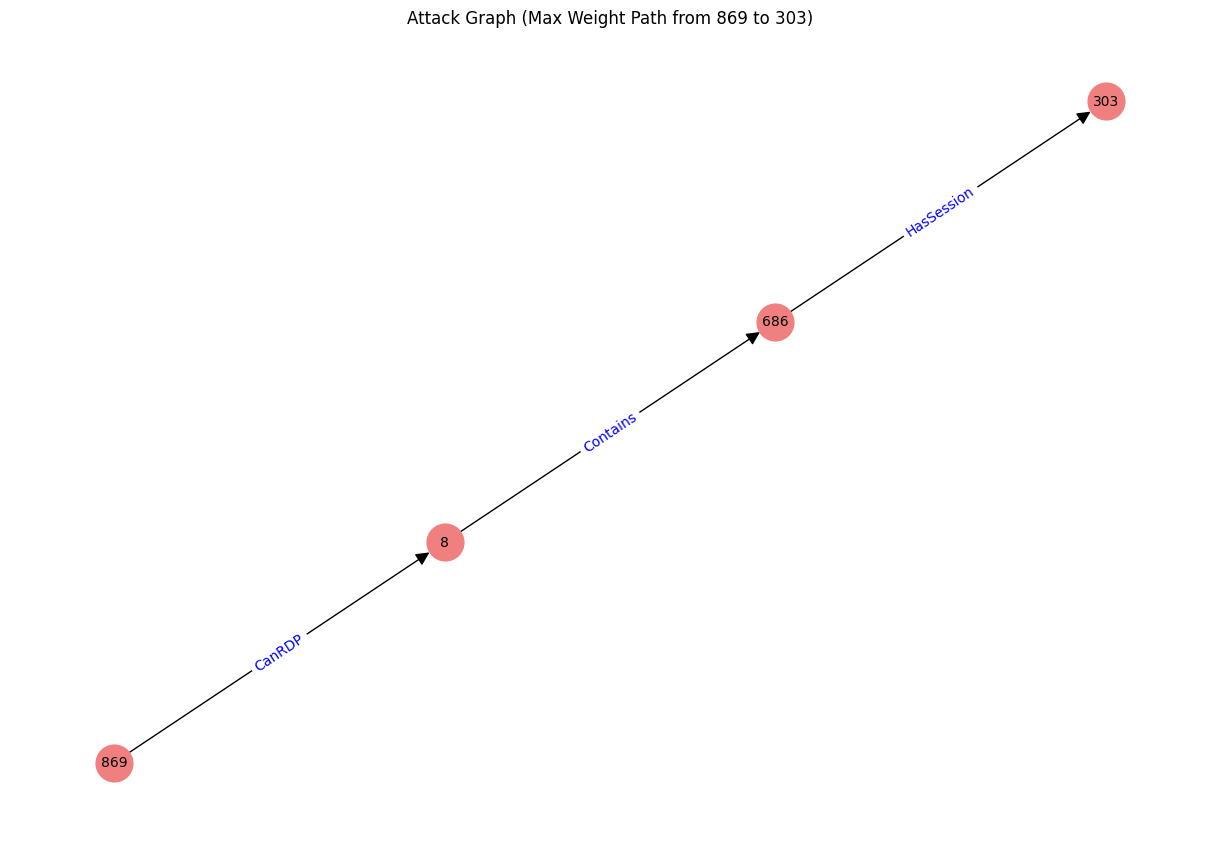

In [136]:
# prompt: using max_weight_row plot the attack graph using networkx starting at the bottom left and ending up top right

import matplotlib.pyplot as plt
# Create a graph for the attack path using the max_weight_row
attack_graph_max = nx.DiGraph()

# Add nodes from the max_weight_row path
path_nodes_max = max_weight_row['path']
for node_id in path_nodes_max:
    # Find the node properties from the original 'nodes' DataFrame
    node_info = nodes[nodes['id'] == node_id].iloc[0]
    attack_graph_max.add_node(node_id, label=node_info.get('name', str(node_id)), weight=node_info.get('weight', 1))

# Add edges from the max_weight_row path
for i in range(len(path_nodes_max) - 1):
    start_node = path_nodes_max[i]
    end_node = path_nodes_max[i+1]
    # Find the edge properties from the original 'edges' DataFrame
    edge_info = edges[(edges['start'] == start_node) & (edges['end'] == end_node)].iloc[0]
    attack_graph_max.add_edge(start_node, end_node, label=edge_info.get('label', 'Unknown'), weight=edge_info.get('weight', 1))

# Draw the graph
# Use a different layout that allows positioning
pos_max = {}
num_nodes = len(path_nodes_max)
# Simple linear positioning from bottom left to top right
for i, node_id in enumerate(path_nodes_max):
    pos_max[node_id] = (i, i) # Positions nodes diagonally

plt.figure(figsize=(12, 8))
nx.draw(attack_graph_max, pos_max, with_labels=False, node_size=700, node_color='lightcoral', font_size=10, arrowsize=20)

# Add node labels
node_labels_max = nx.get_node_attributes(attack_graph_max, 'label')
nx.draw_networkx_labels(attack_graph_max, pos_max, labels=node_labels_max, font_size=10)

# Add edge labels
edge_labels_max = nx.get_edge_attributes(attack_graph_max, 'label')
nx.draw_networkx_edge_labels(attack_graph_max, pos_max, edge_labels=edge_labels_max, font_color='blue')

plt.title(f"Attack Graph (Max Weight Path from {max_weight_row['source']} to {max_weight_row['target']})")
plt.show()

      id  \
110  110   

                                                                                                                                                                       properties  \
110  {'domain': 'MARK.LOCAL', 'name': 'PAW Configuration@MARK.LOCAL', 'objectid': 'S-1-5-21-883232822-274137685-4173207997-d37c9c32-7ad3-4495-862c-b8c9734a1860', 'owned': False}   

     type    l1   l2    l3  weight  
110  node  Base  GPO  None       1  
   id  \
8   8   

                                                                                                                                                                                                                                                                                                      properties  \
8  {'domain': 'MARK.LOCAL', 'name': 'T0 Admin Devices@MARK.LOCAL', 'objectid': 'S-1-5-21-883232822-274137685-4173207997-b9fd1aed-b3e6-4d53-9242-b85ff389822f', 'distinguishedname': 'OU=T0 ADMIN DEVICES,DC=MARK,DC

In [94]:
/1


<>:1: SyntaxWarning: 'int' object is not callable; perhaps you missed a comma?
<>:1: SyntaxWarning: 'int' object is not callable; perhaps you missed a comma?
/tmp/ipython-input-94-691856829.py:1: SyntaxWarning: 'int' object is not callable; perhaps you missed a comma?
  1()


TypeError: 'int' object is not callable

In [ ]:
df_shortest_paths_with_weight

In [137]:
# prompt: for each source find minimum weight and target. if weight is the same print out all instances

import pandas as pd
# Group by source and find the minimum weight
min_weights = df_shortest_paths_with_weight.groupby('source')['total_weight'].min().reset_index()

# Merge with the original DataFrame to get rows with the minimum weight
result_min = pd.merge(df_shortest_paths_with_weight, min_weights, on=['source', 'total_weight'])

# Print the results
# for index, row in result.iterrows():
#   print(f"Source: {row['source']}, Target: {row['target']}, Minimum Weight: {row['total_weight']}, Path: {row['path']}")


In [ ]:
# prompt: for each source find MAXIMUM weight and target. only save the max results in result_max

import pandas as pd
# Group by source and find the maximum weight
max_weights = df_shortest_paths_with_weight.groupby('source')['total_weight'].max().reset_index()

# Merge with the original DataFrame to get rows with the maximum weight
result_max = pd.merge(df_shortest_paths_with_weight, max_weights, on=['source', 'total_weight'])

# Print the results
for index, row in result_max.iterrows():
  print(f"Source: {row['source']}, Target: {row['target']}, Maximum Weight: {row['total_weight']}, Path: {row['path']}")

In [ ]:
# prompt: for each source find minimum weight and target. if weight is the same print out all instances

import pandas as pd
# Group by source and find the minimum weight
max_weights = df_shortest_paths_with_weight.groupby('source')['total_weight'].max().reset_index()

# Merge with the original DataFrame to get rows with the minimum weight
result_max = pd.merge(df_shortest_paths_with_weight, max_weights, on=['source', 'total_weight'])

# Print the results
# for index, row in result.iterrows():
#   print(f"Source: {row['source']}, Target: {row['target']}, Max Weight: {row['total_weight']}, Path: {row['path']}")
# df_shortest_paths_with_weight = pd.DataFrame(shortest_paths_with_weight)
# df_shortest_paths_with_weight

In [ ]:
# prompt: for each source IN df_shortest_paths_with_weight find maximum weight and target AND PATH. if weight is the same print out all instances

# Iterate through each unique source node
for source_node in df_shortest_paths_with_weight['source'].unique():
    # Filter the DataFrame for the current source node
    source_df = df_shortest_paths_with_weight[df_shortest_paths_with_weight['source'] == source_node].copy()

    # Find the maximum weight for this source
    max_weight_for_source = source_df['total_weight'].max()

    # Filter for rows with the maximum weight for this source
    max_weight_paths = source_df[source_df['total_weight'] == max_weight_for_source]

    # Print the results for the current source
    print(f"\nSource: {source_node}")
    print(f"Maximum Weight for this source: {max_weight_for_source}")
    print("Paths with maximum weight:")
    for index, row in max_weight_paths.iterrows():
        print(f"  Target: {row['target']}, Path: {row['path']}")

In [ ]:
result_min

In [ ]:
result_max

In [ ]:
# prompt: show me where source appears the most within the results_max dataframe. is ther one source that appears most

source_counts = result_max['source'].value_counts()

print("Count of each source in result_max:")
print(source_counts)

most_frequent_source = source_counts.index[0]
most_frequent_count = source_counts.iloc[0]

print(f"\nThe source that appears most frequently is: {most_frequent_source} with a count of {most_frequent_count}")

if most_frequent_count > 1:
  print("Yes, there is one source that appears most.")
else:
  print("No single source appears most frequently (or all sources appear only once).")

In [ ]:
source_counts_min = result_min['source'].value_counts()

print("Count of each source in result_max:")
print(source_counts_min)

most_frequent_source_min = source_counts.index[0]
most_frequent_count_min = source_counts.iloc[0]

print(f"\nThe source that appears most frequently is: {most_frequent_source} with a count of {most_frequent_count}")

if most_frequent_count_min > 1:
  print("Yes, there is one source that appears most.")
else:
  print("No single source appears most frequently (or all sources appear only once).")

In [139]:
# prompt: convert result into a DataFrame

import pandas as pd
df_shortest_paths_with_weight = pd.DataFrame(shortest_paths_with_weight)
df_shortest_paths_with_weight

,source,target,path,total_weight
0,15,301,"[15, 301]",2
1,15,318,"[15, 318]",2
2,26,331,"[26, 331]",2
3,26,341,"[26, 341]",2
4,26,357,"[26, 357]",2
5,26,405,"[26, 405]",2
6,26,444,"[26, 444]",2
7,26,448,"[26, 448]",2
8,27,392,"[27, 392]",2
9,29,481,"[29, 481]",2


In [ ]:
print(edges[edges['end'] == 301])

In [ ]:
shortest_paths_with_weight

In [ ]:
# prompt: for each node in shortest_paths_with_weight, find the minimum total_weight and the maxium total_weight, save it to a DataFrame

import pandas as pd
# Initialize a dictionary to store min and max weights for each target node
target_node_weights = {}

# Iterate through the shortest paths
for path_info in shortest_paths_with_weight:
    target_node = path_info['target']
    total_weight = path_info['total_weight']

    if target_node not in target_node_weights:
        target_node_weights[target_node] = {'min_weight': float('inf'), 'max_weight': float('-inf')}

    # Update min and max weights
    target_node_weights[target_node]['min_weight'] = min(target_node_weights[target_node]['min_weight'], total_weight)
    target_node_weights[target_node]['max_weight'] = max(target_node_weights[target_node]['max_weight'], total_weight)

# Convert the dictionary to a DataFrame
min_max_weights_df = pd.DataFrame.from_dict(target_node_weights, orient='index')
min_max_weights_df.index.name = 'target_node'
min_max_weights_df = min_max_weights_df.reset_index()

# Display the resulting DataFrame
print("\nMin and Max Total Weights for Each Target Node:")
min_max_weights_df

In [ ]:
# prompt: for each record in "for each record in "shortest_paths_filtered" add up the weights and find the smallest and largest combined weights and the path

# Find the path with the smallest total weight
min_weight_path_info = min(shortest_paths_with_weight, key=lambda item: item['total_weight'])

# Find the path with the largest total weight
max_weight_path_info = max(shortest_paths_with_weight, key=lambda item: item['total_weight'])

print("\nPath with the Smallest Combined Weight:")
print(f"Source: {min_weight_path_info['source']}, Target: {min_weight_path_info['target']}, Total Weight: {min_weight_path_info['total_weight']}, Path: {min_weight_path_info['path']}")

print("\nPath with the Largest Combined Weight:")
print(f"Source: {max_weight_path_info['source']}, Target: {max_weight_path_info['target']}, Total Weight: {max_weight_path_info['total_weight']}, Path: {max_weight_path_info['path']}")

In [ ]:
# prompt: for each record in "shortest_paths_filtered" add up the weights and find the smallest and largest combined weights and the path for the largest weight

# Function to calculate the total weight of a path
# def calculate_path_weight(graph, path):
#     total_weight = 0
#     for i in range(len(path) - 1):
#         # Add node weight
#         total_weight += graph.nodes[path[i]].get('weight', 0)
#         # Add edge weight
#         total_weight += graph[path[i]][path[i+1]].get('weight', 0)
#     # Add the weight of the last node in the path
#     if path:
#         total_weight += graph.nodes[path[-1]].get('weight', 0)
#     return total_weight

# all_path_weights = {}

# # Iterate through each source and its paths in shortest_paths_filtered
# for source, paths_from_source in shortest_paths_list.items():
#     all_path_weights[source] = {}
#     # Iterate through each target and its path
#     for target, path in paths_from_source.items():
#         # Calculate the weight of the path using the original graph G
#         weight = calculate_path_weight(G, path)
#         all_path_weights[source][target] = weight

# # Find the smallest and largest combined weights
# min_weight = float('inf')
# max_weight = float('-inf')
# largest_weight_path = None
# largest_weight_source = None
# largest_weight_target = None

# for source, paths_from_source in all_path_weights.items():
#     for target, weight in paths_from_source.items():
#         if weight < min_weight:
#             min_weight_source = source
#             min_weight_target = target
#             min_weight_path = shortest_paths_filtered[source][target]
#             min_weight = weight
#         if weight > max_weight:
#             max_weight = weight
#             largest_weight_source = source
#             largest_weight_target = target
#             largest_weight_path = shortest_paths_filtered[source][target]

# print(f"Smallest combined weight: {min_weight}")
# print(f"Path for the smallest weight: {min_weight_path}")
# print(f"Source for the smallest weight path: {min_weight_source}")
# print(f"Target for the smallest weight path: {min_weight_target}")
# print(f"Largest combined weight: {max_weight}")
# print(f"Path for the largest weight: {largest_weight_path}")
# print(f"Source for the largest weight path: {largest_weight_source}")
# print(f"Target for the largest weight path: {largest_weight_target}")

In [ ]:

print(nodes[nodes['id'] == 111])
print(nodes[nodes['id'] == 8])
print(nodes[nodes['id'] == 26])
#print(nodes[nodes['id'] == 444])
#print(nodes[nodes['id'] == 331])
#print(nodes[nodes['id'] == 208])

In [ ]:
selected_nodes

In [ ]:
selected_nodes

In [ ]:
pd.set_option("display.max_rows", None, "display.max_columns", None)
shortest_paths

In [ ]:
shortest_paths_filtered

In [ ]:
# prompt: can you display the combined weight from the shortest_paths and display the path with the max weight

# Function to calculate the total weight of a path
def calculate_path_weight(graph, path):
    total_weight = 0
    # Add the weight of the starting node
    if path:
        total_weight += graph.nodes[path[0]].get('weight', 0) # Get node weight
    # Add the weight of the edges and the weights of subsequent nodes
    for i in range(len(path) - 1):
        u, v = path[i], path[i+1]
        # Add edge weight
        total_weight += graph.edges[u, v].get('weight', 0) # Get edge weight
        # Add weight of the next node
        total_weight += graph.nodes[v].get('weight', 0) # Get node weight
    return total_weight

max_weight = -1
max_path = None

# Iterate through the filtered shortest paths and calculate total weights
for source, paths in shortest_paths_filtered.items():
    for target, path in paths.items():
        current_weight = calculate_path_weight(G, path)
#        print(f"Path from {source} to {target}: {path}, Combined Weight: {current_weight}")
        if current_weight > max_weight:
            max_weight = current_weight
            max_path = path

print(f"\nPath with the maximum combined weight: {max_path}")
print(f"Maximum combined weight: {max_weight}")

In [ ]:
max_path
max_path = pd.DataFrame(max_path)
max_path.head()


In [ ]:
rename = {0: 'id'}
max_path = max_path.rename(columns=rename)
max_path

In [ ]:
# prompt: get label from nodes where id=max_path['id']

# Assuming max_path is a DataFrame with an 'id' column representing the node IDs in the max path
# and nodes is a DataFrame with 'id' and 'properties' columns.

# Get the list of node IDs from the max_path DataFrame
max_path_node_ids = max_path['id'].tolist()

# Filter the nodes DataFrame to get only the nodes that are in the max_path
nodes_in_max_path = nodes[nodes['id'].isin(max_path_node_ids)].copy()

# Now, extract the 'name' property from the 'properties' column for these nodes
# Use .loc to avoid SettingWithCopyWarning
# We use a lambda function with .apply to safely access nested dictionary keys.
max_path_node_labels = nodes_in_max_path.loc[:, 'properties'].apply(lambda x: x.get('name', ''))

print("Labels of nodes in the max path:")
print(max_path_node_labels.tolist())


In [ ]:
max_path

ignore from here


In [ ]:
vertices = nodes['id'].tolist()
vertices


In [ ]:
adj_list=adj.values.tolist()
len(adj_list)

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

def createAdjacencyMatrix(vertices,edges):
  noofvertices=len(vertices)
  adjM=[]
  while(len(adjM)<noofvertices):
    temp=[]
    for i in range(noofvertices):
      temp.append(0)
    adjM.append(temp)
  for edge in edges:
    i=edge[0]
    j=edge[1]
    if i>=noofvertices or j>=noofvertices or i<0 or j<0:
      print(f"Not a Proper Input in Edge {i},{j}")
    else:
      adjM[i][j]=1
      adjM[j][i]=1
#  G=nx.Graph()
#  G.add_edges_from(edges)
#  nx.draw_networkx(G)
#  plt.show()
  return adjM
vertices = vertices
edges = adj_list
adjM=createAdjacencyMatrix(vertices,edges)


In [ ]:
#adjM.shape
import numpy as np
len(adjM)
arr = np.array(adjM)

newarr = arr.reshape(10075, 10075)

print(newarr)

In [ ]:
def create_adjacency_matrix(V, edges):
    # Initialize an empty V x V matrix with all zeros
    matrix = [[0] * V for _ in range(V)]

    # Populate the matrix based on the edges
    for edge in edges:
        u, v = edge
        matrix[u][v] = 1
#       matrix[v][u] = 1  # Undirected graph

    return matrix
V1 = len(adj)
edges1 = adj[['start', 'end']].values.tolist()
adj_matrix1 = create_adjacency_matrix(V1, edges1)
for row in adj_matrix1:
    print(row)
print()

In [ ]:
type(adj)